In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
losses = np.load("../outputs/losses_seed_0.npy")
train_acc = np.load("../outputs/train_acc_seed_0.npy")
val_acc = np.load("../outputs/val_acc_seed_0.npy")

print("Loaded successfully")

Loaded successfully


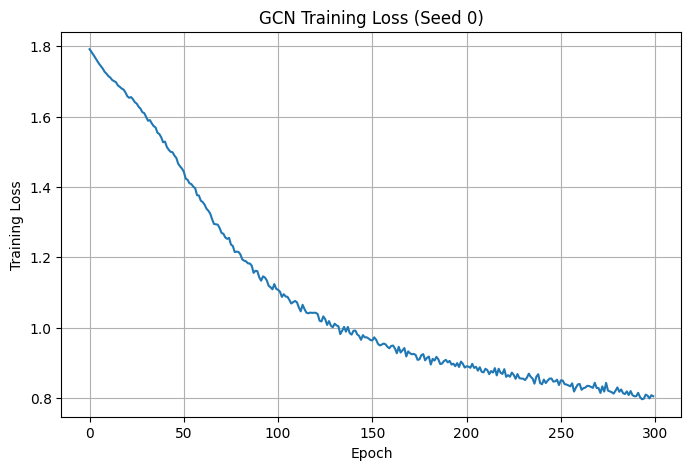

In [3]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("GCN Training Loss (Seed 0)")
plt.grid(True)
plt.show()

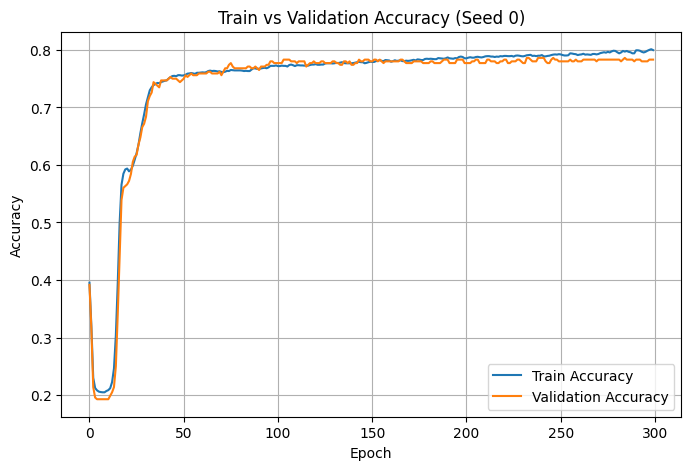

In [4]:
plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy (Seed 0)")
plt.legend()
plt.grid(True)
plt.show()

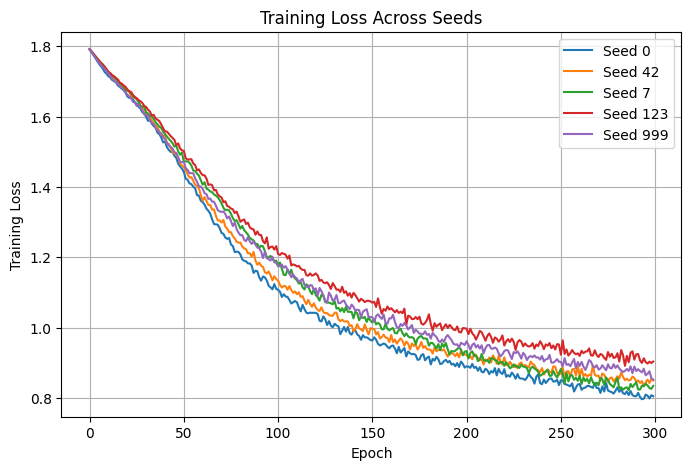

In [5]:
plt.figure(figsize=(8,5))

for seed in [0, 42, 7, 123, 999]:
    losses = np.load(f"../outputs/losses_seed_{seed}.npy")
    plt.plot(losses, label=f"Seed {seed}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Seeds")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import torch

checkpoint = torch.load("/Users/smathur/citeseer_project/Data/raw/CiteSeer/processed/data.pt")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch_geometric.data.data.Data was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.Data])` or the `torch.serialization.safe_globals([torch_geometric.data.data.Data])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to lea

In [ ]:
print(checkpoint)

({'x': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), 'edge_index': tensor([[ 628,  158,  486,  ..., 2820, 1643,   33],
        [   0,    1,    1,  ..., 3324, 3325, 3326]]), 'y': tensor([3, 1, 5,  ..., 3, 1, 5]), 'train_mask': tensor([ True,  True,  True,  ..., False, False, False]), 'val_mask': tensor([False, False, False,  ..., False, False, False]), 'test_mask': tensor([False, False, False,  ...,  True,  True,  True])}, None, <class 'torch_geometric.data.data.Data'>)


In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import ipywidgets as widgets

from torch_geometric.utils import to_networkx
from src.data_preprocessing import load_data
from src.model import APPNPModel   # change to GCN if needed


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

dataset, data = load_data(device, split_type="random")

print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Features per node:", dataset.num_node_features)
print("Classes:", dataset.num_classes)

Processing...
Done!


Nodes: 3327
Edges: 9104
Features per node: 3703
Classes: 6


In [ ]:
checkpoint = torch.load("/Users/smathur/citeseer_project/models/appnp_best_seed_0.pt", map_location=device)

model = APPNPModel(
    dataset.num_node_features,
    64,
    dataset.num_classes,
    K=10,
    alpha=0.1,
    dropout=0.5
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = torch.exp(out)  # convert from log_softmax
    preds = probs.argmax(dim=1)

print("Model loaded and inference completed ✅")

Model loaded and inference completed ✅


In [ ]:
label_names = [
    "Agents",
    "AI",
    "DB",
    "IR",
    "ML",
    "HCI"
]

In [ ]:
def show_paper(node_id):
    true_label = data.y[node_id].item()
    pred_label = preds[node_id].item()
    confidence = probs[node_id][pred_label].item()

    neighbor_count = (data.edge_index[0] == node_id).sum().item()

    print("====================================")
    print(f"📄 Paper ID: {node_id}")
    print(f"🔎 True Label: {label_names[true_label]}")
    print(f"🤖 Predicted Label: {label_names[pred_label]}")
    print(f"📊 Confidence: {confidence:.4f}")
    print(f"🔗 Number of Citations: {neighbor_count}")
    print("====================================")

In [ ]:
show_paper(300)

📄 Paper ID: 300
🔎 True Label: ML
🤖 Predicted Label: ML
📊 Confidence: 0.8910
🔗 Number of Citations: 5


In [ ]:
G = to_networkx(data, to_undirected=True)

In [ ]:
def get_subgraph(node_id, num_neighbors=15):
    neighbors = list(G.neighbors(node_id))[:num_neighbors]
    nodes = neighbors + [node_id]
    return G.subgraph(nodes)

In [ ]:
def plot_node_prediction(node_id):
    subG = get_subgraph(node_id)

    plt.figure(figsize=(8,6))

    colors = []
    for node in subG.nodes():
        colors.append(preds[node].item())

    nx.draw(
        subG,
        with_labels=True,
        node_color=colors,
        cmap=plt.cm.tab10,
        node_size=700,
        font_size=8
    )

    plt.title(f"Node {node_id} and Neighbors (Predicted Labels)")
    plt.show()

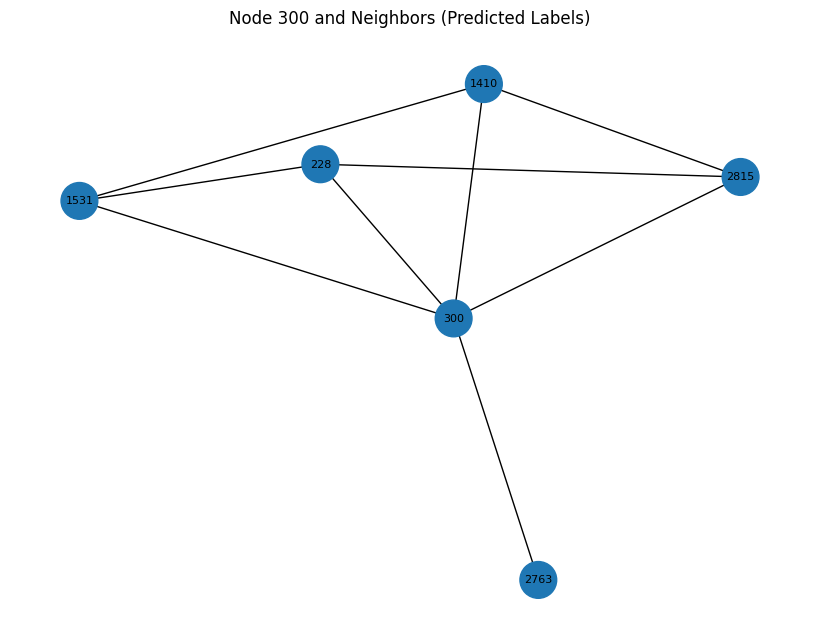

In [ ]:
plot_node_prediction(300)

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

Dataset Statistics
--------------------
Number of Nodes: 3327
Number of Edges: 9104
Number of Features: 3703
Number of Classes: 6

Class Distribution


,Class,Count
0,Agents,264
1,AI,590
2,DB,668
3,IR,701
4,ML,596
5,HCI,508


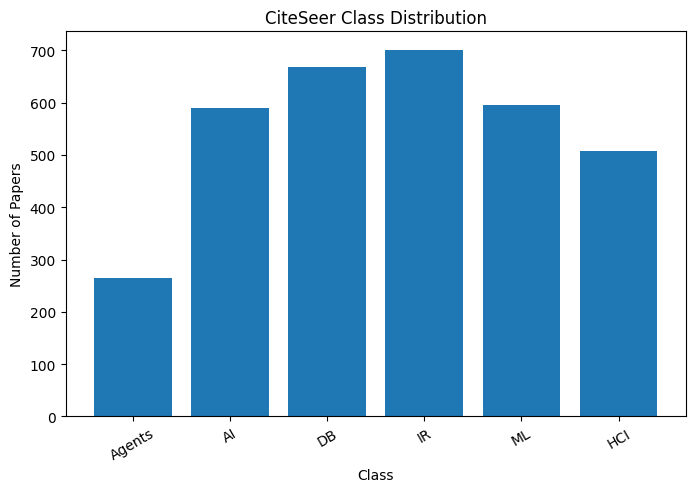

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from src.data_preprocessing import load_data

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

dataset, data = load_data(device, split_type="random_80_10_10")

# ------------------------
# Basic Dataset Statistics
# ------------------------
num_nodes = data.num_nodes
num_edges = data.num_edges
num_features = dataset.num_node_features
num_classes = dataset.num_classes

print("Dataset Statistics")
print("--------------------")
print(f"Number of Nodes: {num_nodes}")
print(f"Number of Edges: {num_edges}")
print(f"Number of Features: {num_features}")
print(f"Number of Classes: {num_classes}")

# ------------------------
# Class Distribution
# ------------------------
labels = data.y.cpu().numpy()

class_counts = Counter(labels)

class_names = ["Agents", "AI", "DB", "IR", "ML", "HCI"]

counts = [class_counts[i] for i in range(num_classes)]

df = pd.DataFrame({
    "Class": class_names,
    "Count": counts
})

print("\nClass Distribution")
display(df)

# ------------------------
# Plot Class Distribution
# ------------------------
plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.title("CiteSeer Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Papers")
plt.xticks(rotation=30)
plt.show()

,K,Mean Accuracy,Std Dev
0,5,0.799401,0.009277
1,10,0.793413,0.007085
2,20,0.788024,0.006932


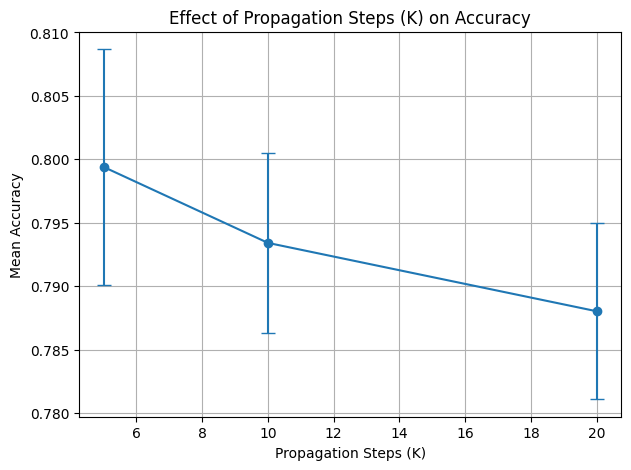

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Example results from your experiment
K_values = [5, 10, 20]
mean_accuracy = [0.799401, 0.793413, 0.788024]
std_dev = [0.009277, 0.007085, 0.006932]

df_k = pd.DataFrame({
    "K": K_values,
    "Mean Accuracy": mean_accuracy,
    "Std Dev": std_dev
})

display(df_k)

plt.figure(figsize=(7,5))
plt.errorbar(K_values, mean_accuracy, yerr=std_dev, marker='o', capsize=5)
plt.title("Effect of Propagation Steps (K) on Accuracy")
plt.xlabel("Propagation Steps (K)")
plt.ylabel("Mean Accuracy")
plt.grid(True)
plt.show()

,Alpha,Mean Accuracy,Std Dev
0,0.1,0.797006,0.005151
1,0.2,0.797006,0.009912
2,0.5,0.804192,0.005553


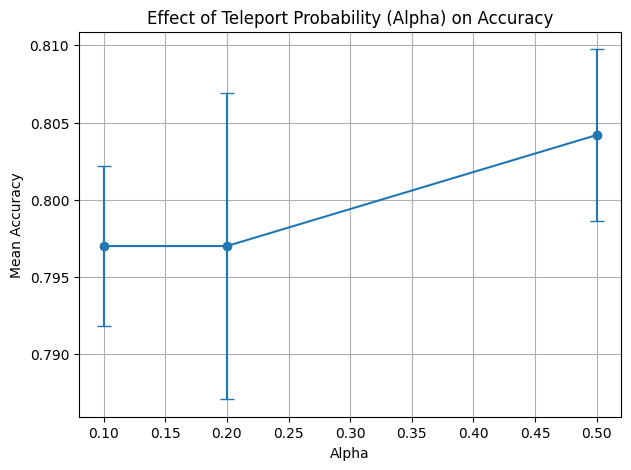

In [ ]:
alpha_values = [0.1, 0.2, 0.5]
mean_accuracy = [0.797006, 0.797006, 0.804192]
std_dev = [0.005151, 0.009912, 0.005553]

df_alpha = pd.DataFrame({
    "Alpha": alpha_values,
    "Mean Accuracy": mean_accuracy,
    "Std Dev": std_dev
})

display(df_alpha)

plt.figure(figsize=(7,5))
plt.errorbar(alpha_values, mean_accuracy, yerr=std_dev, marker='o', capsize=5)
plt.title("Effect of Teleport Probability (Alpha) on Accuracy")
plt.xlabel("Alpha")
plt.ylabel("Mean Accuracy")
plt.grid(True)
plt.show()

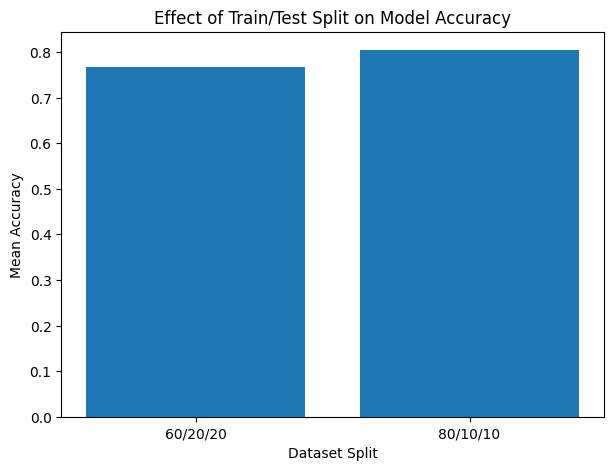

In [ ]:
splits = ["60/20/20", "80/10/10"]
accuracy = [0.766967, 0.804192]

plt.figure(figsize=(7,5))
plt.bar(splits, accuracy)
plt.title("Effect of Train/Test Split on Model Accuracy")
plt.xlabel("Dataset Split")
plt.ylabel("Mean Accuracy")
plt.show()